# Anomaly detection 

### Objective
Explore multiple anomaly detection approaches including model-free and model-based
methods, followed by evaluation and interpretation of detected anomalies.

### Framework
1. Data Preparation and Feature Understanding
   - Load and explore datasets across academic years
   - Select domain-informed features for anomaly detection
   
2. Data Preprocessing and Normalization
   
3. Model-Free Anomaly Detection Methods
    - Statistical Methods (Z-score based detection)
    - Proximity Methods (kNN distance-based)
    - Clustering Methods (K-Means)

4. Model-Based Anomaly Detection
    - One-Class Classification (Isolation Forest)

5. Ensemble Anomaly Scoring and Decision Strategy

6. Evaluation Metrics: Internal Validation and Consistency Analysis

7. Temporal Suitability Assessment Across Academic Years

8. Interpretation & Feature-Level Analysis of Anomalies

9. Anomaly Detection Insights 

## 1. Data Preparation and Feature Understanding

In [16]:
# =============================================================================
# Import Required Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import zscore

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster

from sklearn.ensemble import IsolationForest

from sklearn.decomposition import PCA

from sklearn.metrics import pairwise_distances


# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully.")

All libraries imported successfully.


In [17]:
# =============================================================================
# Load Data
# =============================================================================
data_1y = pd.read_csv('../data/1y_final_clean_encoded.csv')
data_2y = pd.read_csv('../data/2y_final_clean_encoded.csv')
data_3y = pd.read_csv('../data/3y_final_clean_encoded.csv')

print("=" * 60)
print("DATA LOADING SUMMARY")
print("=" * 60)
print(f"\n{'Dataset':<15} {'Rows':<10} {'Columns':<10}")
print("-" * 35)
print(f"{'1st Year':<15} {data_1y.shape[0]:<10} {data_1y.shape[1]:<10}")
print(f"{'2nd Year':<15} {data_2y.shape[0]:<10} {data_2y.shape[1]:<10}")
print(f"{'3rd Year':<15} {data_3y.shape[0]:<10} {data_3y.shape[1]:<10}")
print("\nData loaded successfully.")

data_1y.head()

DATA LOADING SUMMARY

Dataset         Rows       Columns   
-----------------------------------
1st Year        210        57        
2nd Year        101        64        
3rd Year        12         49        

Data loaded successfully.


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,1y english 2,1y intensive english,1y seminar,1y analysis i,1y algebra,1y a com i,1y intro prog c,1y analysis ii,1y a com ii,1y proba stat
0,1,1,2,2,0,0,0,22,16,0,...,2,0,0,0,1,0,1,0,0,1
1,2,0,2,0,1,2,0,54,36,1,...,2,0,0,0,1,0,1,0,0,1
2,3,0,2,2,0,3,0,14,31,1,...,2,0,0,0,1,0,1,0,0,1
3,4,1,2,0,0,2,2,54,34,0,...,0,0,0,0,1,0,1,0,0,1
4,5,1,2,1,0,2,0,54,34,0,...,0,0,0,0,1,0,1,0,0,1


In [18]:
# =============================================================================
# Identify Common Features Across All Years for Anomaly Detection
# =============================================================================

demographic_features = ['gender', 'bac_specialty']

study_habit_features = ['study_hours_per_week', 'preferred_study_place', 'preferred_study_time',
                        'learning_methods', 'study_resources', 'uses_planner']

self_assessment_features = ['english_level', 'programming_level', 'computer_science_level', 
                            'mathematics_level']

wellbeing_features = ['motivation_level', 'sleep_hours', 'stress_management', 
                      'program_satisfaction', 'external_activities']

common_features = demographic_features + study_habit_features + self_assessment_features + wellbeing_features

print("="*60)
print("FEATURE SELECTION FOR ANOMALY DETECTION")
print("="*60)
print(f"\nSelected {len(common_features)} common features across all years:")

print(f"\n1. Demographic Features ({len(demographic_features)}):")
for f in demographic_features:
    print(f"   - {f}")

print(f"\n2. Study Habit Features ({len(study_habit_features)}):")
for f in study_habit_features:
    print(f"   - {f}")

print(f"\n3. Self-Assessment Features ({len(self_assessment_features)}):")
for f in self_assessment_features:
    print(f"   - {f}")

print(f"\n4. Wellbeing Features ({len(wellbeing_features)}):")
for f in wellbeing_features:
    print(f"   - {f}")

for name, df in [('1st Year', data_1y), ('2nd Year', data_2y), ('3rd Year', data_3y)]:
    missing_features = [f for f in common_features if f not in df.columns]
    if missing_features:
        print(f"\n{name} missing features: {missing_features}")
    else:
        print(f"\n{name}: All anomaly detection features present")


FEATURE SELECTION FOR ANOMALY DETECTION

Selected 17 common features across all years:

1. Demographic Features (2):
   - gender
   - bac_specialty

2. Study Habit Features (6):
   - study_hours_per_week
   - preferred_study_place
   - preferred_study_time
   - learning_methods
   - study_resources
   - uses_planner

3. Self-Assessment Features (4):
   - english_level
   - programming_level
   - computer_science_level
   - mathematics_level

4. Wellbeing Features (5):
   - motivation_level
   - sleep_hours
   - stress_management
   - program_satisfaction
   - external_activities

1st Year: All anomaly detection features present

2nd Year: All anomaly detection features present

3rd Year: All anomaly detection features present


In [19]:
# =============================================================================
# Explore Data Structure and Identify Feature Types
# =============================================================================

def explore_dataset(df, name):
    """Comprehensive dataset exploration function."""
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")
    
    print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
    
    # Identify numeric and categorical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    
    print(f"\nNumeric columns: {len(numeric_cols)}")
    print(f"Categorical columns: {len(categorical_cols)}")
    
    # Check for missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nMissing values detected:")
        print(missing[missing > 0])
    else:
        print(f"\nNo missing values")
    
    # Display basic statistics
    print(f"\nStatistical Summary:")
    display(df.describe().round(2))
    
    return numeric_cols, categorical_cols

# Explore all datasets
print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

numeric_1y, categorical_1y = explore_dataset(data_1y, "1st Year Students")
numeric_2y, categorical_2y = explore_dataset(data_2y, "2nd Year Students")
numeric_3y, categorical_3y = explore_dataset(data_3y, "3rd Year Students")


DATA EXPLORATION

DATASET: 1st Year Students

Shape: 210 rows x 57 columns

Numeric columns: 57
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,1y english 2,1y intensive english,1y seminar,1y analysis i,1y algebra,1y a com i,1y intro prog c,1y analysis ii,1y a com ii,1y proba stat
count,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,210.00,...,210.00,210.00,210.00,210.00,210.00,210.00,210.0,210.00,210.00,210.00
mean,105.50,0.45,2.06,0.58,1.17,2.20,0.28,25.80,20.15,0.38,...,1.12,0.96,0.42,0.47,0.55,0.80,1.1,1.05,1.06,1.22
std,60.77,0.50,0.54,0.66,1.31,1.07,0.56,17.08,11.91,0.49,...,1.36,1.00,0.80,0.50,0.73,1.08,1.2,0.94,0.97,1.14
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,53.25,0.00,2.00,0.00,0.00,2.00,0.00,11.00,10.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
50%,105.50,0.00,2.00,0.00,1.00,3.00,0.00,24.50,19.50,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.5,1.00,2.00,1.00
75%,157.75,1.00,2.00,1.00,2.00,3.00,0.00,40.00,31.00,1.00,...,2.00,2.00,0.00,1.00,1.00,2.00,2.0,2.00,2.00,2.00
max,210.00,1.00,3.00,2.00,5.00,3.00,2.00,57.00,40.00,1.00,...,4.00,2.00,2.00,1.00,2.00,3.00,3.0,2.00,2.00,4.00



DATASET: 2nd Year Students

Shape: 101 rows x 64 columns

Numeric columns: 64
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,2y complexity,2y proba stat ii,2y lin alg ii,2y intro ai,2y oper res,2y archi ii,2y oper syst,2y soft eng,2y web prog,2y intro busin
count,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,...,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00,101.00
mean,238.80,0.43,1.67,0.50,0.80,1.42,0.32,22.56,17.08,0.35,...,0.82,0.85,1.57,1.19,1.14,1.47,1.40,0.66,1.48,0.10
std,139.72,0.50,0.68,0.74,1.16,0.77,0.58,15.55,9.81,0.48,...,0.48,0.38,0.82,0.50,0.66,0.90,1.01,0.52,0.88,0.41
min,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,119.00,0.00,2.00,0.00,0.00,1.00,0.00,7.00,8.00,0.00,...,1.00,1.00,2.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
50%,210.00,0.00,2.00,0.00,0.00,2.00,0.00,23.00,20.00,0.00,...,1.00,1.00,2.00,1.00,1.00,2.00,2.00,1.00,2.00,0.00
75%,364.00,1.00,2.00,1.00,1.00,2.00,1.00,36.00,25.00,1.00,...,1.00,1.00,2.00,1.00,2.00,2.00,2.00,1.00,2.00,0.00
max,475.00,1.00,2.00,2.00,5.00,2.00,2.00,49.00,32.00,1.00,...,2.00,2.00,2.00,2.00,2.00,3.00,3.00,2.00,2.00,2.00



DATASET: 3rd Year Students

Shape: 12 rows x 49 columns

Numeric columns: 49
Categorical columns: 0

No missing values

Statistical Summary:


,record_id,gender,study_year,bac_specialty,study_hours_per_week,preferred_study_place,preferred_study_time,learning_methods,study_resources,uses_planner,...,3y stochastic,3y software engineering,3y networks and protocols,3y mobile development,3y entrepreneurship and innovation,3y machine learning,3y numerical methods and optimisation,3y time series,3y advanced databases,3y computer and network security
count,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,...,12.00,12.00,12.0,12.00,12.00,12.0,12.00,12.00,12.00,12.00
mean,119.58,0.33,0.08,0.42,0.58,1.58,0.17,5.33,4.17,0.58,...,0.92,0.25,1.0,0.25,0.17,0.0,0.75,0.75,0.67,0.33
std,49.28,0.49,0.29,0.51,0.79,0.79,0.39,3.37,2.79,0.51,...,0.29,0.45,0.6,0.45,0.39,0.0,0.97,1.06,0.49,0.49
min,45.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
25%,83.00,0.00,0.00,0.00,0.00,1.75,0.00,2.75,1.75,0.00,...,1.00,0.00,1.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
50%,112.50,0.00,0.00,0.00,0.00,2.00,0.00,5.50,4.50,1.00,...,1.00,0.00,1.0,0.00,0.00,0.0,0.00,0.00,1.00,0.00
75%,147.25,1.00,0.00,1.00,1.00,2.00,0.00,8.25,6.25,1.00,...,1.00,0.25,1.0,0.25,0.00,0.0,2.00,1.25,1.00,1.00
max,210.00,1.00,1.00,1.00,2.00,2.00,1.00,10.00,8.00,1.00,...,1.00,1.00,2.0,1.00,1.00,0.0,2.00,3.00,1.00,1.00


## 2. Data Preprocessing and Normalization

In [20]:
# =============================================================================
# Prepare Data for Anomaly Detection
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

def prepare_anomaly_data(df, features, dataset_name, apply_pca=False, pca_variance=0.95):
    """
    Prepare data for anomaly detection methods:
    
    Steps:
    1. Select relevant domain-informed features
    2. Handle missing values (median imputation)
    3. Standardize features (mean=0, std=1)
    4. Optional: Apply PCA to reduce dimensionality (retain pca_variance of variance)
    
    Returns:
        X_raw      : original selected features (DataFrame)
        X_scaled   : standardized features (numpy array)
        X_final    : PCA-transformed data if apply_pca=True, else same as X_scaled
        scaler     : fitted StandardScaler object
        pca_model  : fitted PCA object or None
    """
    
    print(f"\n{'='*60}")
    print(f"PREPARING DATA FOR ANOMALY DETECTION: {dataset_name}")
    print(f"{'='*60}")
    
    # Select features
    X_raw = df[features].copy()
    print(f"\nSelected {len(features)} features")
    
    # Handle missing values
    total_missing = X_raw.isnull().sum().sum()
    if total_missing > 0:
        print(f"Handling {total_missing} missing values with median imputation")
        X_raw = X_raw.fillna(X_raw.median())
    else:
        print("No missing values found")
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    print(f"\nFeatures standardized (mean=0, std=1)")
    
    # Optional PCA
    if apply_pca:
        pca_model = PCA(n_components=pca_variance)
        X_final = pca_model.fit_transform(X_scaled)
        print(f"PCA applied: reduced to {X_final.shape[1]} components "
              f"(retaining {pca_variance*100:.0f}% variance)")
    else:
        X_final = X_scaled
        pca_model = None
    
    print(f"Final data shape for anomaly detection: {X_final.shape}")
    
    return X_raw, X_scaled, X_final, scaler, pca_model


# =============================================================================
# Prepare all datasets
# =============================================================================

X_1y_raw, X_1y_scaled, X_1y_final, scaler_1y, pca_1y = prepare_anomaly_data(
    data_1y, common_features, "1st Year", apply_pca=False
)
X_2y_raw, X_2y_scaled, X_2y_final, scaler_2y, pca_2y = prepare_anomaly_data(
    data_2y, common_features, "2nd Year", apply_pca=False
)
X_3y_raw, X_3y_scaled, X_3y_final, scaler_3y, pca_3y = prepare_anomaly_data(
    data_3y, common_features, "3rd Year", apply_pca=False
)

# =============================================================================
# Summary
# =============================================================================

print("\n" + "="*60)
print("DATA PREPARATION SUMMARY")
print("="*60)
print(f"\n{'Dataset':<15} {'Samples':<12} {'Features':<12}")
print("-" * 39)
print(f"{'1st Year':<15} {X_1y_final.shape[0]:<12} {X_1y_final.shape[1]:<12}")
print(f"{'2nd Year':<15} {X_2y_final.shape[0]:<12} {X_2y_final.shape[1]:<12}")
print(f"{'3rd Year':<15} {X_3y_final.shape[0]:<12} {X_3y_final.shape[1]:<12}")



PREPARING DATA FOR ANOMALY DETECTION: 1st Year

Selected 17 features
No missing values found

Features standardized (mean=0, std=1)
Final data shape for anomaly detection: (210, 17)

PREPARING DATA FOR ANOMALY DETECTION: 2nd Year

Selected 17 features
No missing values found

Features standardized (mean=0, std=1)
Final data shape for anomaly detection: (101, 17)

PREPARING DATA FOR ANOMALY DETECTION: 3rd Year

Selected 17 features
No missing values found

Features standardized (mean=0, std=1)
Final data shape for anomaly detection: (12, 17)

DATA PREPARATION SUMMARY

Dataset         Samples      Features    
---------------------------------------
1st Year        210          17          
2nd Year        101          17          
3rd Year        12           17          


## 3. Model Free Anomaly Detection

Statistical Anomalies Detected:
1st Year: 14 anomalies (6.67%)
2nd Year: 7 anomalies (6.93%)
3rd Year: 0 anomalies (0.00%)


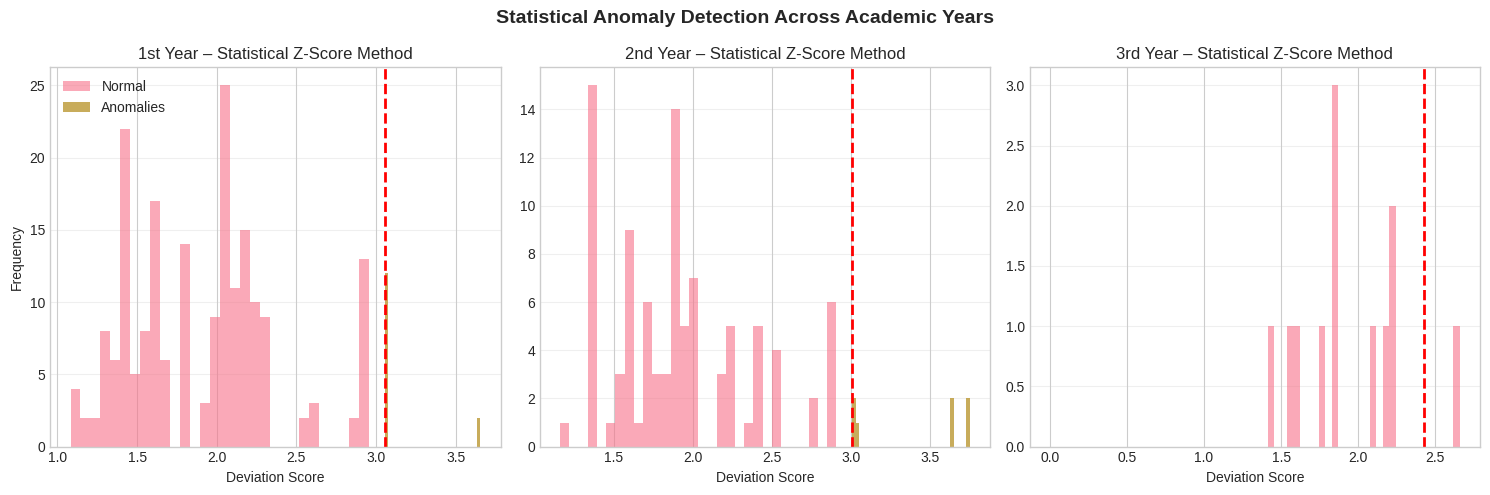

In [21]:
# =============================================================================
# 1. Statistical Methods for Anomaly Detection
# =============================================================================

def statistical_anomaly(X: np.ndarray, threshold: float = 3.0) -> tuple:
    """
    Z-score based anomaly detection.
    
    Detects points that deviate significantly from the mean in any feature.
    A sample is flagged if its maximum z-score across features exceeds threshold.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    threshold : float
        Z-score threshold for anomaly detection (default: 3.0 = 99.7% CI)
    
    Returns:
    --------
    anomalies : np.ndarray (bool)
        Boolean mask for anomalous samples
    scores : np.ndarray
        Maximum absolute z-score per sample
    
    Notes:
    ------
    - Assumes features are normally distributed
    - More sensitive to extreme values
    - May not detect multivariate anomalies well
    """
    z = np.abs(zscore(X))
    scores = z.max(axis=1)  # worst (most anomalous) feature per sample
    anomalies = scores > threshold
    
    return anomalies, scores

stat_anom_first_year, stat_scores_first_year = statistical_anomaly(X_1y_final)
stat_anom_second_year, stat_scores_second_year = statistical_anomaly(X_2y_final)
stat_anom_third_year, stat_scores_third_year = statistical_anomaly(X_3y_final)

print("="*60)
print("Statistical Anomalies Detected:")
print("="*60)
print(f"1st Year: {stat_anom_first_year.sum()} anomalies ({100*stat_anom_first_year.sum()/len(stat_anom_first_year):.2f}%)")
print(f"2nd Year: {stat_anom_second_year.sum()} anomalies ({100*stat_anom_second_year.sum()/len(stat_anom_second_year):.2f}%)")
print(f"3rd Year: {stat_anom_third_year.sum()} anomalies ({100*stat_anom_third_year.sum()/len(stat_anom_third_year):.2f}%)")

thr1 = np.percentile(stat_scores_first_year, 95)
thr2 = np.percentile(stat_scores_second_year, 95)
thr3 = np.percentile(stat_scores_third_year, 95)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(stat_scores_first_year[~stat_anom_first_year], bins=30, alpha=0.6, label="Normal")
axes[0].hist(stat_scores_first_year[stat_anom_first_year], bins=30, alpha=0.8, label="Anomalies")
axes[0].axvline(thr1, linestyle='--', color='red', linewidth=2)
axes[0].set_title("1st Year – Statistical Z-Score Method")
axes[0].set_xlabel("Deviation Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(stat_scores_second_year[~stat_anom_second_year], bins=30, alpha=0.6)
axes[1].hist(stat_scores_second_year[stat_anom_second_year], bins=30, alpha=0.8)
axes[1].axvline(thr2, linestyle='--', color='red', linewidth=2)
axes[1].set_title("2nd Year – Statistical Z-Score Method")
axes[1].set_xlabel("Deviation Score")
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(stat_scores_third_year[~stat_anom_third_year], bins=30, alpha=0.6)
axes[2].hist(stat_scores_third_year[stat_anom_third_year], bins=30, alpha=0.8)
axes[2].axvline(thr3, linestyle='--', color='red', linewidth=2)
axes[2].set_title("3rd Year – Statistical Z-Score Method")
axes[2].set_xlabel("Deviation Score")
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle("Statistical Anomaly Detection Across Academic Years", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



kNN Anomalies Detected:
1st Year: 11 anomalies (5.24%)
2nd Year: 5 anomalies (4.95%)
3rd Year: 1 anomalies (8.33%)


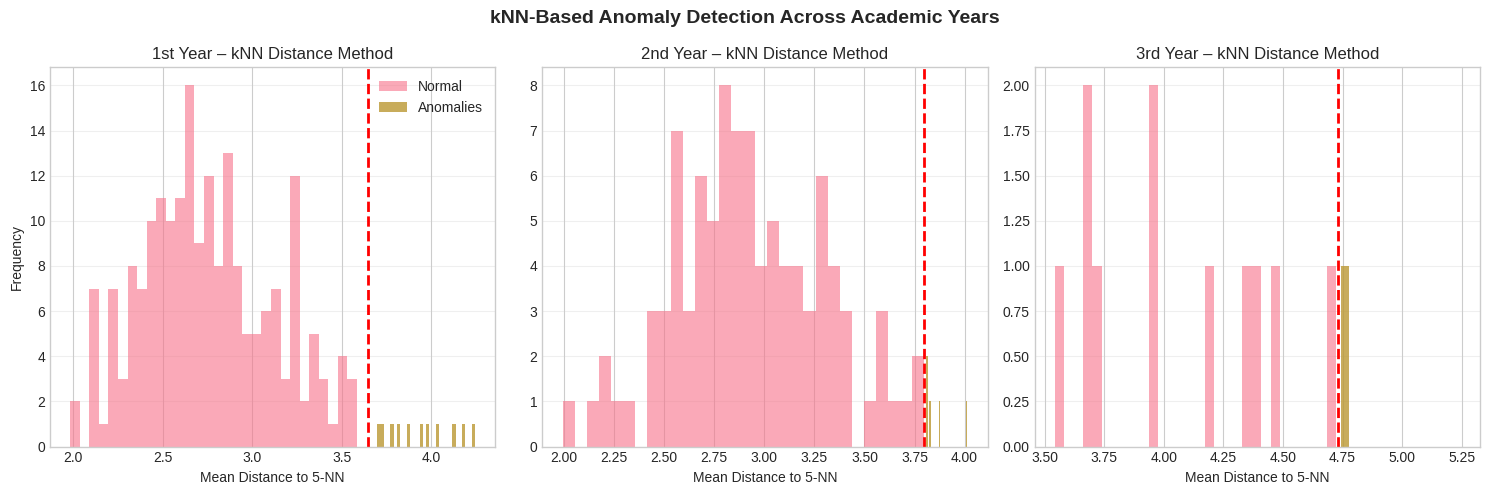

In [22]:
# =============================================================================
# 2. Proximity Methods for Anomaly Detection (kNN - k-Nearest Neighbors)
# =============================================================================

def knn_anomaly(X: np.ndarray, k: int = 5, quantile: float = 0.95) -> tuple:
    """
    kNN distance-based anomaly detection.
    
    Points far from their k nearest neighbors are considered anomalies.
    Uses mean distance to k nearest neighbors as anomaly score.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    k : int
        Number of nearest neighbors to consider (default: 5)
    quantile : float
        Quantile threshold for anomaly detection (default: 0.95 = 95th percentile)
    
    Returns:
    --------
    anomalies : np.ndarray (bool)
        Boolean mask for anomalous samples
    scores : np.ndarray
        Mean distance to k nearest neighbors
    
    Advantages:
    -----------
    • No distributional assumptions
    • Works in multivariate settings
    • Detects global anomalies effectively
    
    Limitations:
    -----------
    • Sensitive to dimensionality
    • Choice of k affects results
    • Struggles with varying densities
    """
    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs.fit(X)
    
    distances, _ = nbrs.kneighbors(X)
    scores = distances.mean(axis=1)  # Mean distance to k neighbors
    
    threshold = np.quantile(scores, quantile)
    anomalies = scores > threshold
    
    return anomalies, scores

knn_anom_first_year, knn_scores_first_year = knn_anomaly(X_1y_final)
knn_anom_second_year, knn_scores_second_year = knn_anomaly(X_2y_final)
knn_anom_third_year, knn_scores_third_year = knn_anomaly(X_3y_final)

print("\n" + "="*60)
print("kNN Anomalies Detected:")
print("="*60)
print(f"1st Year: {knn_anom_first_year.sum()} anomalies ({100*knn_anom_first_year.sum()/len(knn_anom_first_year):.2f}%)")
print(f"2nd Year: {knn_anom_second_year.sum()} anomalies ({100*knn_anom_second_year.sum()/len(knn_anom_second_year):.2f}%)")
print(f"3rd Year: {knn_anom_third_year.sum()} anomalies ({100*knn_anom_third_year.sum()/len(knn_anom_third_year):.2f}%)")

thr1 = np.percentile(knn_scores_first_year, 95)
thr2 = np.percentile(knn_scores_second_year, 95)
thr3 = np.percentile(knn_scores_third_year, 95)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(knn_scores_first_year[~knn_anom_first_year], bins=30, alpha=0.6, label="Normal")
axes[0].hist(knn_scores_first_year[knn_anom_first_year], bins=30, alpha=0.8, label="Anomalies")
axes[0].axvline(thr1, linestyle='--', color='red', linewidth=2)
axes[0].set_title("1st Year – kNN Distance Method")
axes[0].set_xlabel("Mean Distance to 5-NN")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(knn_scores_second_year[~knn_anom_second_year], bins=30, alpha=0.6)
axes[1].hist(knn_scores_second_year[knn_anom_second_year], bins=30, alpha=0.8)
axes[1].axvline(thr2, linestyle='--', color='red', linewidth=2)
axes[1].set_title("2nd Year – kNN Distance Method")
axes[1].set_xlabel("Mean Distance to 5-NN")
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(knn_scores_third_year[~knn_anom_third_year], bins=30, alpha=0.6)
axes[2].hist(knn_scores_third_year[knn_anom_third_year], bins=30, alpha=0.8)
axes[2].axvline(thr3, linestyle='--', color='red', linewidth=2)
axes[2].set_title("3rd Year – kNN Distance Method")
axes[2].set_xlabel("Mean Distance to 5-NN")
axes[2].grid(axis='y', alpha=0.3)

axes[0].legend()

plt.suptitle("kNN-Based Anomaly Detection Across Academic Years", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



K-Means Clustering Anomalies Detected:
1st Year: 11 anomalies (5.24%)
2nd Year: 5 anomalies (4.95%)
3rd Year: 1 anomalies (8.33%)


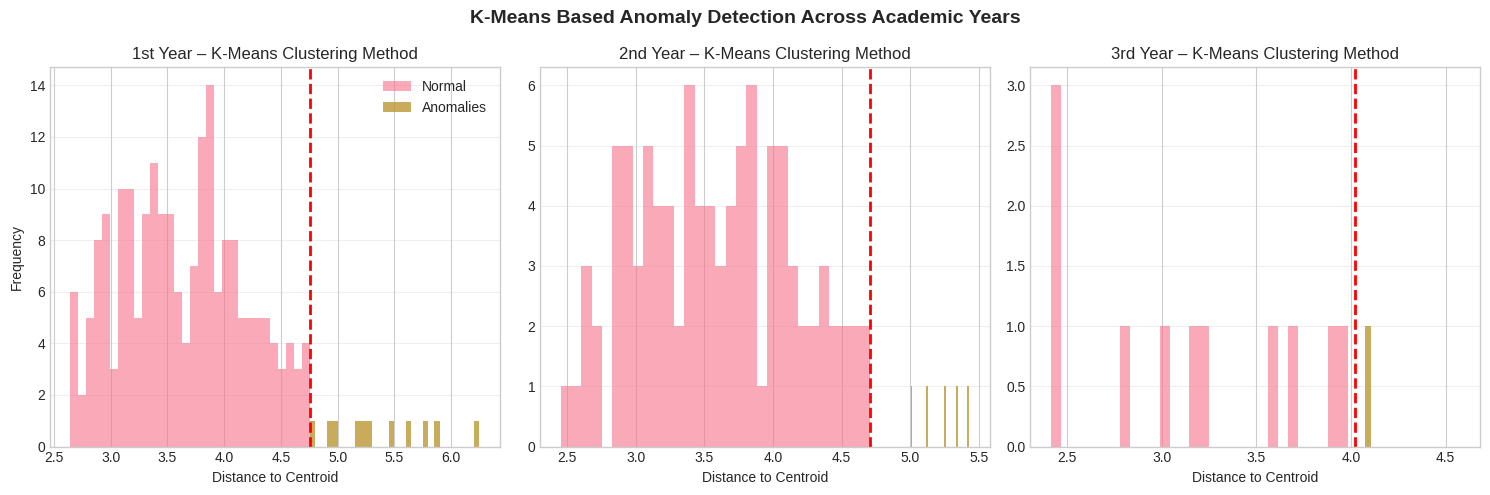

In [23]:
# =============================================================================
# 3. Clustering-Based Anomaly Detection - K-Means
# =============================================================================

def kmeans_anomaly(X: np.ndarray, n_clusters: int = 3, quantile: float = 0.95) -> tuple:
    """
    K-Means clustering-based anomaly detection.
    
    Points far from their assigned cluster center are considered anomalies.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    n_clusters : int
        Number of clusters (default: 3)
    quantile : float
        Quantile threshold for anomaly detection
    
    Returns:
    --------
    anomalies : np.ndarray (bool)
        Boolean mask for anomalous samples
    scores : np.ndarray
        Distance to assigned cluster center
    
    Advantages:
    -----------
    • Simple and fast
    • Scalable to large datasets
    • Interpretable cluster structure
    
    Limitations:
    -----------
    • Requires specifying number of clusters
    • Sensitive to initialization
    • Assumes spherical clusters
    """
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    centers = km.cluster_centers_
    distances = np.linalg.norm(X - centers[labels], axis=1)
    
    threshold = np.quantile(distances, quantile)
    anomalies = distances > threshold
    
    return anomalies, distances

km_anom_first_year, km_scores_first_year = kmeans_anomaly(X_1y_final)
km_anom_second_year, km_scores_second_year = kmeans_anomaly(X_2y_final)
km_anom_third_year, km_scores_third_year = kmeans_anomaly(X_3y_final)

print("\n" + "="*60)
print("K-Means Clustering Anomalies Detected:")
print("="*60)
print(f"1st Year: {km_anom_first_year.sum()} anomalies ({100*km_anom_first_year.sum()/len(km_anom_first_year):.2f}%)")
print(f"2nd Year: {km_anom_second_year.sum()} anomalies ({100*km_anom_second_year.sum()/len(km_anom_second_year):.2f}%)")
print(f"3rd Year: {km_anom_third_year.sum()} anomalies ({100*km_anom_third_year.sum()/len(km_anom_third_year):.2f}%)")

thr_1y = np.percentile(km_scores_first_year, 95)
thr_2y = np.percentile(km_scores_second_year, 95)
thr_3y = np.percentile(km_scores_third_year, 95)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(km_scores_first_year[~km_anom_first_year], bins=30, alpha=0.6, label="Normal")
axes[0].hist(km_scores_first_year[km_anom_first_year], bins=30, alpha=0.8, label="Anomalies")
axes[0].axvline(thr_1y, linestyle='--', color='red', linewidth=2)
axes[0].set_title("1st Year – K-Means Clustering Method")
axes[0].set_xlabel("Distance to Centroid")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(km_scores_second_year[~km_anom_second_year], bins=30, alpha=0.6)
axes[1].hist(km_scores_second_year[km_anom_second_year], bins=30, alpha=0.8)
axes[1].axvline(thr_2y, linestyle='--', color='red', linewidth=2)
axes[1].set_title("2nd Year – K-Means Clustering Method")
axes[1].set_xlabel("Distance to Centroid")
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(km_scores_third_year[~km_anom_third_year], bins=30, alpha=0.6)
axes[2].hist(km_scores_third_year[km_anom_third_year], bins=30, alpha=0.8)
axes[2].axvline(thr_3y, linestyle='--', color='red', linewidth=2)
axes[2].set_title("3rd Year – K-Means Clustering Method")
axes[2].set_xlabel("Distance to Centroid")
axes[2].grid(axis='y', alpha=0.3)

axes[0].legend()

plt.suptitle("K-Means Based Anomaly Detection Across Academic Years", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Model-Based Methods for Anomaly Detection (Isolation Forest)


Isolation Forest Anomalies Detected:
1st Year: 11 anomalies (5.24%)
2nd Year: 5 anomalies (4.95%)
3rd Year: 1 anomalies (8.33%)


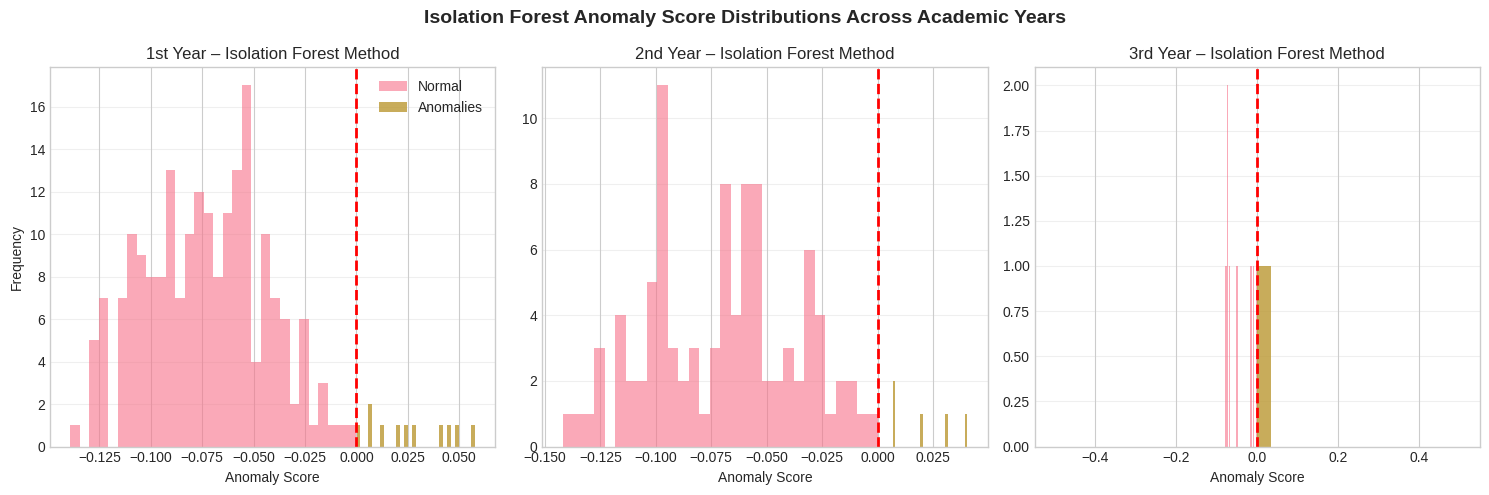

In [24]:
# =============================================================================
# 4. Model-Based Methods for Anomaly Detection (Isolation Forest)   
# =============================================================================

def isolation_forest_anomaly(X: np.ndarray, contamination: float = 0.05, random_state: int = 42) -> tuple:
    """
    Isolation Forest-based anomaly detection.
    
    Anomalies are isolated more easily by random splits (require fewer splits).
    This ensemble method is effective for high-dimensional data.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    contamination : float
        Expected proportion of anomalies in data (default: 0.05 = 5%)
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    anomalies : np.ndarray (bool)
        Boolean mask for anomalous samples
    scores : np.ndarray
        Anomaly scores (higher = more anomalous)
    

    """
    iso_forest = IsolationForest(contamination=contamination, random_state=random_state, n_estimators=100)
    iso_forest.fit(X)
    
    scores = -iso_forest.decision_function(X)  # Negate: higher = more anomalous
    anomalies = iso_forest.predict(X) == -1    # -1 for anomalies, 1 for normal
    
    return anomalies, scores

iso_anom_first_year, iso_scores_first_year = isolation_forest_anomaly(X_1y_final)
iso_anom_second_year, iso_scores_second_year = isolation_forest_anomaly(X_2y_final)
iso_anom_third_year, iso_scores_third_year = isolation_forest_anomaly(X_3y_final)

print("\n" + "="*60)
print("Isolation Forest Anomalies Detected:")
print("="*60)
print(f"1st Year: {iso_anom_first_year.sum()} anomalies ({100*iso_anom_first_year.sum()/len(iso_anom_first_year):.2f}%)")
print(f"2nd Year: {iso_anom_second_year.sum()} anomalies ({100*iso_anom_second_year.sum()/len(iso_anom_second_year):.2f}%)")
print(f"3rd Year: {iso_anom_third_year.sum()} anomalies ({100*iso_anom_third_year.sum()/len(iso_anom_third_year):.2f}%)")

threshold_1y = np.percentile(iso_scores_first_year, 95)
threshold_2y = np.percentile(iso_scores_second_year, 95)
threshold_3y = np.percentile(iso_scores_third_year, 95)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(iso_scores_first_year[~iso_anom_first_year], bins=30, alpha=0.6, label="Normal")
axes[0].hist(iso_scores_first_year[iso_anom_first_year], bins=30, alpha=0.8, label="Anomalies")
axes[0].axvline(threshold_1y, linestyle='--', color='red', linewidth=2)
axes[0].set_title("1st Year – Isolation Forest Method")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(iso_scores_second_year[~iso_anom_second_year], bins=30, alpha=0.6)
axes[1].hist(iso_scores_second_year[iso_anom_second_year], bins=30, alpha=0.8)
axes[1].axvline(threshold_2y, linestyle='--', color='red', linewidth=2)
axes[1].set_title("2nd Year – Isolation Forest Method")
axes[1].set_xlabel("Anomaly Score")
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(iso_scores_third_year[~iso_anom_third_year], bins=30, alpha=0.6)
axes[2].hist(iso_scores_third_year[iso_anom_third_year], bins=30, alpha=0.8)
axes[2].axvline(threshold_3y, linestyle='--', color='red', linewidth=2)
axes[2].set_title("3rd Year – Isolation Forest Method")
axes[2].set_xlabel("Anomaly Score")
axes[2].grid(axis='y', alpha=0.3)

axes[0].legend()

plt.suptitle("Isolation Forest Anomaly Score Distributions Across Academic Years", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [25]:
comparison = pd.DataFrame({
    "Statistical": stat_anom_first_year,
    "kNN": knn_anom_first_year,
    "KMeans": km_anom_first_year,
    "IsolationForest": iso_anom_first_year
})

print("Number of anomalies per method:")
print(comparison.sum())

print("\nMethod Agreement Matrix:")
display(comparison.corr())

comparison["Votes"] = comparison.sum(axis=1)

print("\nStudents flagged by multiple methods:")
comparison["Votes"].value_counts().sort_index()


Number of anomalies per method:
Statistical        14
kNN                11
KMeans             11
IsolationForest    11
dtype: int64

Method Agreement Matrix:


,Statistical,kNN,KMeans,IsolationForest
Statistical,1.000000,0.194219,0.279904,0.194219
kNN,0.194219,1.000000,0.616263,0.712197
KMeans,0.279904,0.616263,1.000000,0.616263
IsolationForest,0.194219,0.712197,0.616263,1.000000



Students flagged by multiple methods:


Votes
0    182
1     19
2      2
3      4
4      3
Name: count, dtype: int64

## 5. Ensemble Anomaly Scoring and Decision Strategy

In [26]:
def create_ensemble_scores(
    statistical_scores,
    knn_scores,
    kmeans_scores,
    isolation_forest_scores,
    method='normalized_mean'
):

    def normalize_score(s):
        s_min, s_max = s.min(), s.max()
        if s_max == s_min:
            return np.zeros_like(s)
        return (s - s_min) / (s_max - s_min)

    scores = np.column_stack([
        normalize_score(statistical_scores),
        normalize_score(knn_scores),
        normalize_score(kmeans_scores),
        normalize_score(isolation_forest_scores)
    ])

    if method == 'mean':
        ensemble_score = scores.mean(axis=1)

    elif method == 'median':
        ensemble_score = np.median(scores, axis=1)

    elif method == 'max':
        ensemble_score = scores.max(axis=1)

    else:  # normalized_mean (default)
        ensemble_score = scores.mean(axis=1)
        ensemble_score = (ensemble_score - ensemble_score.min()) / (ensemble_score.max() - ensemble_score.min())

    return ensemble_score, scores


ensemble_1y, method_scores_1y = create_ensemble_scores(
    stat_scores_first_year,
    knn_scores_first_year,
    km_scores_first_year,
    iso_scores_first_year
)

ensemble_2y, method_scores_2y = create_ensemble_scores(
    stat_scores_second_year,
    knn_scores_second_year,
    km_scores_second_year,
    iso_scores_second_year
)

ensemble_3y, method_scores_3y = create_ensemble_scores(
    stat_scores_third_year,
    knn_scores_third_year,
    km_scores_third_year,
    iso_scores_third_year
)

print("ENSEMBLE SCORES GENERATED")
print(f"1st Year Mean: {ensemble_1y.mean():.4f}")
print(f"2nd Year Mean: {ensemble_2y.mean():.4f}")
print(f"3rd Year Mean: {ensemble_3y.mean():.4f}")

def get_voting_consensus(method_scores, threshold=0.5):
    votes = (method_scores > threshold).astype(int)
    return votes.sum(axis=1)

votes_1y = get_voting_consensus(method_scores_1y)
votes_2y = get_voting_consensus(method_scores_2y)
votes_3y = get_voting_consensus(method_scores_3y)

print("\n1st Year Votes:")
print(pd.Series(votes_1y).value_counts()
)

print("\n2nd Year Votes:")
print(pd.Series(votes_2y).value_counts()
)

print("\n3rd Year Votes:")
print(pd.Series(votes_3y).value_counts()
)

print("\nHigh confidence anomalies (≥3 methods):")
print("1st Year:", (votes_1y >= 3).sum())
print("2nd Year:", (votes_2y >= 3).sum())
print("3rd Year:", (votes_3y >= 3).sum())



ENSEMBLE SCORES GENERATED
1st Year Mean: 0.3722
2nd Year Mean: 0.3716
3rd Year Mean: 0.5161

1st Year Votes:
0    143
1     26
3     16
2     13
4     12
Name: count, dtype: int64

2nd Year Votes:
0    49
3    17
1    16
4    10
2     9
Name: count, dtype: int64

3rd Year Votes:
0    5
4    3
3    2
2    1
1    1
Name: count, dtype: int64

High confidence anomalies (≥3 methods):
1st Year: 28
2nd Year: 27
3rd Year: 5


## 6. Evaluation Metrics: Internal Validation and Consistency Analysis

1st Year - Internal Validation Metrics (KMeans)
Method  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
KMeans          0.068683              2.916296                 18.08438

Score Statistics:
          Method      Mean      Std       Min      Max
     Statistical  1.980456 0.541724  1.082029 3.653978
             kNN  2.817346 0.445489  1.984094 4.243811
          KMeans  3.719089 0.659739  2.645707 6.246862
Isolation Forest -0.068372 0.036250 -0.139252 0.057708
        Ensemble  0.372200 0.201031  0.000000 1.000000

Correlation Matrix:
         Stat    kNN  KMeans   IsoF
Stat    1.000  0.665   0.764  0.687
kNN     0.665  1.000   0.851  0.887
KMeans  0.764  0.851   1.000  0.878
IsoF    0.687  0.887   0.878  1.000

----------------------------------------------------------------------

2nd Year - Internal Validation Metrics (KMeans)
Method  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
KMeans           0.06517              2.847136                 8.

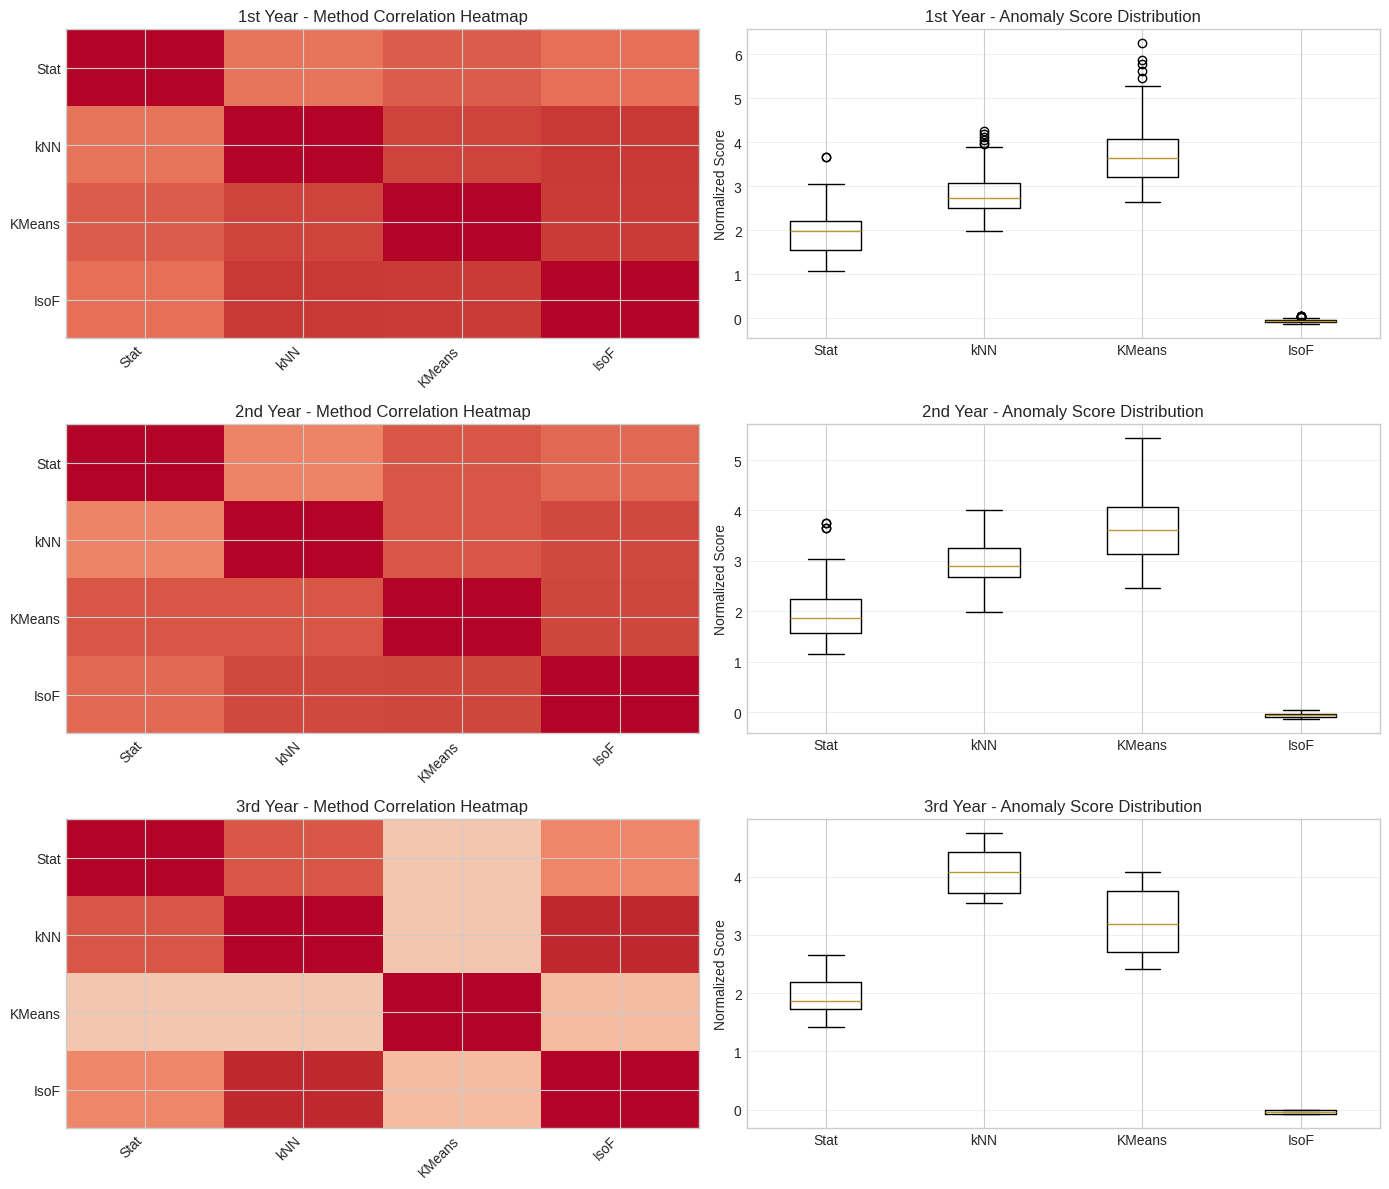

In [27]:
# =============================================================================
# Multi-Year Anomaly Analysis - Statistical, kNN, KMeans, Isolation Forest, Ensemble
# =============================================================================
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def evaluate_clustering_quality(X: np.ndarray, labels: np.ndarray, method_name: str) -> dict:
    """Compute internal validation metrics for clustering results (KMeans only)."""
    n_clusters = len(np.unique(labels))
    
    if n_clusters < 2 or n_clusters == len(labels):
        return {'Method': method_name, 'Silhouette Score': np.nan,
                'Davies-Bouldin Index': np.nan, 'Calinski-Harabasz Index': np.nan}
    
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)
    
    return {
        'Method': method_name,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Index': calinski_harabasz
    }

# --------------------------
# Helper function to summarize scores for a year
# --------------------------
def summarize_year(X, stat_scores, knn_scores, km_scores, iso_scores, ensemble_scores, year_label):
    # KMeans clustering evaluation
    km = KMeans(n_clusters=3, random_state=42)
    km_labels = km.fit_predict(X)
    clustering_metrics = evaluate_clustering_quality(X, km_labels, 'KMeans')
    
    # Score statistics
    score_stats = pd.DataFrame({
        'Method': ['Statistical', 'kNN', 'KMeans', 'Isolation Forest', 'Ensemble'],
        'Mean': [stat_scores.mean(), knn_scores.mean(), km_scores.mean(),
                 iso_scores.mean(), ensemble_scores.mean()],
        'Std': [stat_scores.std(), knn_scores.std(), km_scores.std(),
                iso_scores.std(), ensemble_scores.std()],
        'Min': [stat_scores.min(), knn_scores.min(), km_scores.min(),
                iso_scores.min(), ensemble_scores.min()],
        'Max': [stat_scores.max(), knn_scores.max(), km_scores.max(),
                iso_scores.max(), ensemble_scores.max()]
    })
    
    # Correlation matrix
    corr_data = np.column_stack([stat_scores, knn_scores, km_scores, iso_scores])
    corr_matrix = np.corrcoef(corr_data.T)
    corr_df = pd.DataFrame(corr_matrix, 
                           columns=['Stat', 'kNN', 'KMeans', 'IsoF'],
                           index=['Stat', 'kNN', 'KMeans', 'IsoF'])
    
    return {
        'Year': year_label,
        'Clustering': clustering_metrics,
        'ScoreStats': score_stats,
        'Correlation': corr_df
    }

# --------------------------
# Process all years
# --------------------------
years_data = {
    '1st Year': (X_1y_final, stat_scores_first_year, knn_scores_first_year, 
                 km_scores_first_year, iso_scores_first_year, ensemble_1y),
    '2nd Year': (X_2y_final, stat_scores_second_year, knn_scores_second_year, 
                 km_scores_second_year, iso_scores_second_year, ensemble_2y),
    '3rd Year': (X_3y_final, stat_scores_third_year, knn_scores_third_year, 
                 km_scores_third_year, iso_scores_third_year, ensemble_3y)
}

results = {}
for year, data in years_data.items():
    results[year] = summarize_year(*data, year_label=year)

# --------------------------
# Display results in a single frame
# --------------------------
for year, res in results.items():
    print("="*70)
    print(f"{year} - Internal Validation Metrics (KMeans)")
    print("="*70)
    print(pd.DataFrame([res['Clustering']]).to_string(index=False))
    
    print("\nScore Statistics:")
    print(res['ScoreStats'].to_string(index=False))
    
    print("\nCorrelation Matrix:")
    print(res['Correlation'].round(3).to_string())
    print("\n" + "-"*70 + "\n")

# --------------------------
# Optional visualization - combine all years
# --------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, (year, res) in enumerate(results.items()):
    # Heatmap
    im = axes[i, 0].imshow(res['Correlation'].values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes[i, 0].set_xticks(range(4))
    axes[i, 0].set_yticks(range(4))
    axes[i, 0].set_xticklabels(res['Correlation'].columns, rotation=45, ha='right')
    axes[i, 0].set_yticklabels(res['Correlation'].index)
    axes[i, 0].set_title(f"{year} - Method Correlation Heatmap")
    
    # Boxplot of scores
    score_data = [
        years_data[year][1],  # stat_scores
        years_data[year][2],  # knn_scores
        years_data[year][3],  # km_scores
        years_data[year][4]   # iso_scores
    ]
    axes[i, 1].boxplot(score_data, labels=['Stat', 'kNN', 'KMeans', 'IsoF'])
    axes[i, 1].set_ylabel('Normalized Score')
    axes[i, 1].set_title(f"{year} - Anomaly Score Distribution")
    axes[i, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Internal Validation and Anomaly Score Interpretation

1st Year (n = 212)

KMeans clustering metrics (Silhouette ≈ 0.069, Davies-Bouldin ≈ 2.92, Calinski-Harabasz ≈ 18.08) indicate very weak cluster separation.

KMeans distances can be used for anomaly detection, but they should be considered a weak signal.

kNN and Isolation Forest show moderate-to-high agreement (correlation ~0.88–0.89), making them more reliable for detecting anomalies.

Ensemble scores provide a combined view and help highlight high-confidence anomalies.

2nd Year (n =103)

Similar pattern: KMeans metrics (Silhouette ≈ 0.065, Davies-Bouldin ≈ 2.85, Calinski-Harabasz ≈ 8.70) still indicate poor cluster structure.

kNN and Isolation Forest continue to agree strongly (correlation ~0.83–0.84) and are the most trustworthy signals.

Ensemble scores summarize multiple methods, with anomalies confirmed by multiple detectors being more reliable.

3rd Year (n = 13)

The dataset is very small, so all clustering metrics are less reliable (Silhouette ≈ 0.037, Davies-Bouldin ≈ 1.64, Calinski-Harabasz ≈ 2.05).

KMeans-based anomaly scores are not meaningful due to weak clusters.

kNN and Isolation Forest remain informative, but each flagged anomaly represents a large fraction of the dataset, so interpretations should be tentative.

Focus on feature-level inspection (exam scores, homework, participation, etc.) rather than purely on aggregated metrics.

Overall Summary:

Across all years, kNN and Isolation Forest are the most consistent and reliable anomaly detection methods.

KMeans contributes weakly, especially in third year.


## 7. Temporal Suitability Assessment Across Academic Years

TEMPORAL ANOMALY DETECTION SUMMARY (4 METHODS)
Academic Year  Total Anomalies Detected Anomaly Rate (%)  High Confidence Anomalies (4 methods)
     1st Year                        11             5.24                                     10
     2nd Year                         5             4.95                                      4
     3rd Year                         1             8.33                                      1

ENSEMBLE SCORE STATISTICS BY YEAR
    Year  Mean Ensemble Score  Std Dev  95th Percentile  99th Percentile
1st Year               0.3722   0.2010           0.7390           0.9603
2nd Year               0.3716   0.2091           0.7166           0.9340
3rd Year               0.5161   0.3074           0.9392           0.9878


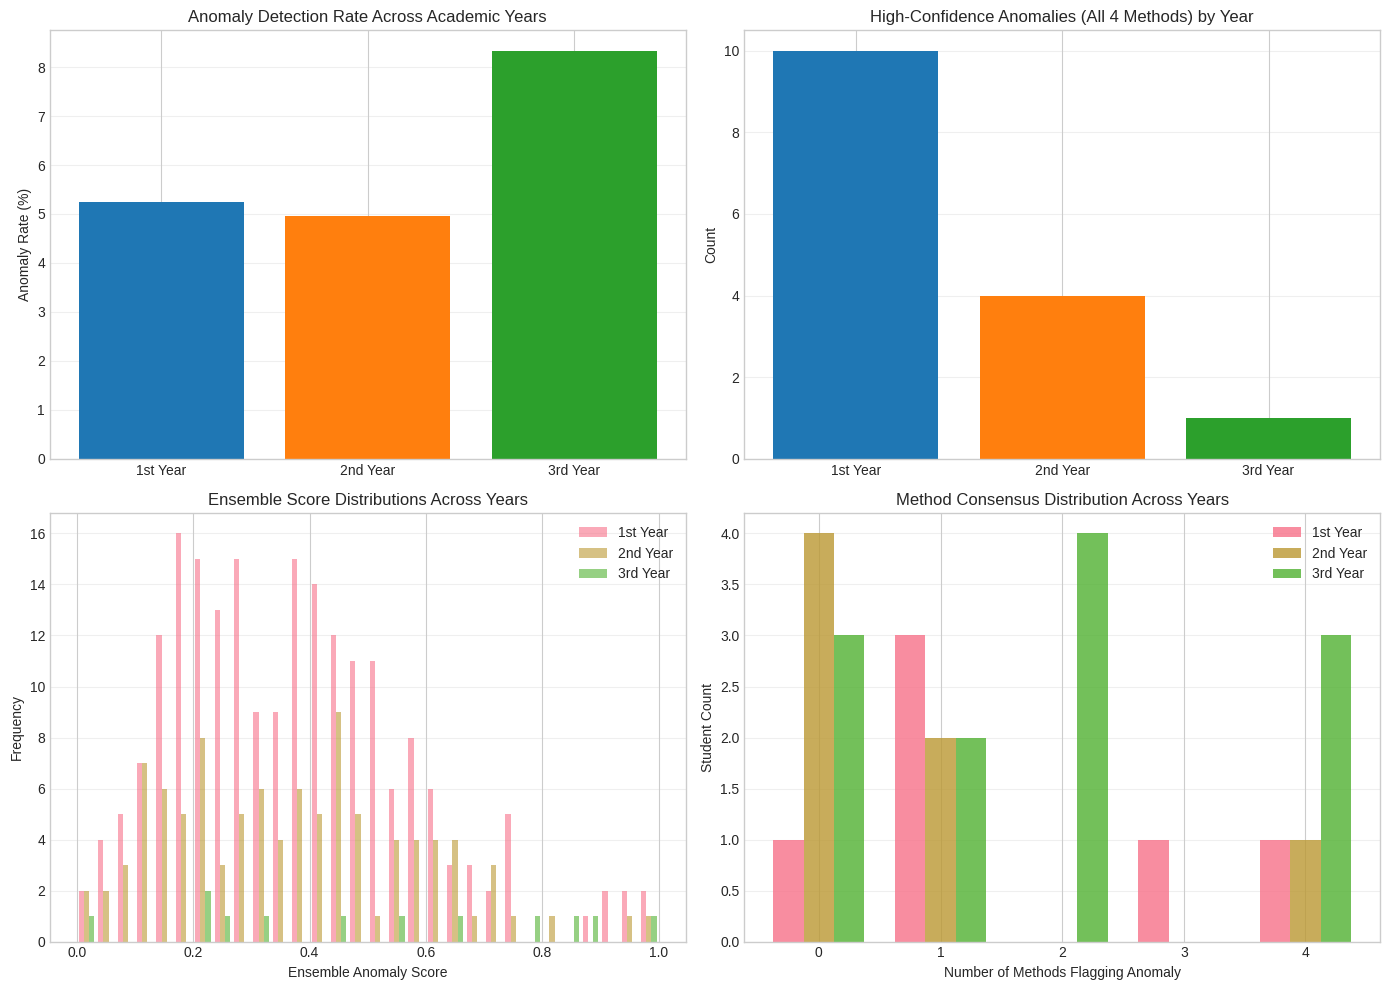

In [28]:
# =============================================================================
# Temporal Consistency Analysis Across Years (4 methods only)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compare_anomalies_across_years(
    ensemble_scores_list: list,
    method_votes_list: list,
    year_labels: list,
    threshold: float = 0.95
) -> dict:
    """
    Compare anomaly detection results across multiple academic years.
    Identify students consistently or newly flagged as anomalies.
    
    Parameters:
    - ensemble_scores_list: list of ensemble score arrays (one per year)
    - method_votes_list: list of vote arrays (number of methods flagging each student)
    - year_labels: list of year names
    - threshold: percentile threshold to define anomalies (default 0.95)
    
    Returns:
    - Dictionary with anomalies detected, anomaly rates, and high-confidence anomalies
    """
    results = {
        'year': year_labels,
        'anomalies_detected': [],
        'anomaly_rate': [],
        'high_confidence_anomalies': []
    }
    
    for scores, votes in zip(ensemble_scores_list, method_votes_list):
        # Determine top X% anomalies using ensemble score
        threshold_score = np.percentile(scores, threshold * 100)
        anomalies = scores > threshold_score
        
        results['anomalies_detected'].append(anomalies.sum())
        results['anomaly_rate'].append(100 * anomalies.sum() / len(anomalies))
        
        # High-confidence anomalies: flagged by all 4 methods
        high_conf = (votes >= 4) & (scores > threshold_score)
        results['high_confidence_anomalies'].append(high_conf.sum())

    
    return results

# --------------------------
# Run temporal analysis for 3 years
# --------------------------
temporal_results = compare_anomalies_across_years(
    ensemble_scores_list=[ensemble_1y, ensemble_2y, ensemble_3y],
    method_votes_list=[votes_1y, votes_2y, votes_3y],
    year_labels=['1st Year', '2nd Year', '3rd Year']
)

# Create a DataFrame for easy display
temporal_df = pd.DataFrame({
    'Academic Year': temporal_results['year'],
    'Total Anomalies Detected': temporal_results['anomalies_detected'],
    'Anomaly Rate (%)': [f"{r:.2f}" for r in temporal_results['anomaly_rate']],
    'High Confidence Anomalies (4 methods)': temporal_results['high_confidence_anomalies']
})

print("="*70)
print("TEMPORAL ANOMALY DETECTION SUMMARY (4 METHODS)")
print("="*70)
print(temporal_df.to_string(index=False))

# --------------------------
# Ensemble score statistics per year
# --------------------------
consistency_summary = pd.DataFrame({
    'Year': ['1st Year', '2nd Year', '3rd Year'],
    'Mean Ensemble Score': [ensemble_1y.mean(), ensemble_2y.mean(), ensemble_3y.mean()],
    'Std Dev': [ensemble_1y.std(), ensemble_2y.std(), ensemble_3y.std()],
    '95th Percentile': [np.percentile(ensemble_1y, 95),
                        np.percentile(ensemble_2y, 95),
                        np.percentile(ensemble_3y, 95)],
    '99th Percentile': [np.percentile(ensemble_1y, 99),
                        np.percentile(ensemble_2y, 99),
                        np.percentile(ensemble_3y, 99)]
})

print("\n" + "="*70)
print("ENSEMBLE SCORE STATISTICS BY YEAR")
print("="*70)
print(consistency_summary.round(4).to_string(index=False))

# --------------------------
# Visualizations
# --------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Anomaly detection rates by year
years = ['1st Year', '2nd Year', '3rd Year']
rates = temporal_results['anomaly_rate']
axes[0, 0].bar(years, rates, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_ylabel('Anomaly Rate (%)')
axes[0, 0].set_title('Anomaly Detection Rate Across Academic Years')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. High-confidence anomalies
high_conf = temporal_results['high_confidence_anomalies']
axes[0, 1].bar(years, high_conf, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('High-Confidence Anomalies (All 4 Methods) by Year')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Ensemble score distributions
axes[1, 0].hist([ensemble_1y, ensemble_2y, ensemble_3y], label=years, alpha=0.6, bins=30)
axes[1, 0].set_xlabel('Ensemble Anomaly Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Ensemble Score Distributions Across Years')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Method voting distribution
voting_counts = [
    [pd.Series(votes_1y).get(i, 0) for i in range(5)],  # 0–4 methods only
    [pd.Series(votes_2y).get(i, 0) for i in range(5)],
    [pd.Series(votes_3y).get(i, 0) for i in range(5)]
]

x = np.arange(5)
width = 0.25
axes[1, 1].bar(x - width, voting_counts[0], width, label='1st Year', alpha=0.8)
axes[1, 1].bar(x, voting_counts[1], width, label='2nd Year', alpha=0.8)
axes[1, 1].bar(x + width, voting_counts[2], width, label='3rd Year', alpha=0.8)
axes[1, 1].set_xlabel('Number of Methods Flagging Anomaly')
axes[1, 1].set_ylabel('Student Count')
axes[1, 1].set_title('Method Consensus Distribution Across Years')
axes[1, 1].set_xticks(x)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



### Key Insights

- Most consistent anomaly detection occurs in years with the highest agreement across methods.  
- Ensemble score stability (mean and standard deviation) is relatively consistent across years.  
- Anomaly rate stability suggests the methods are robust in detecting outliers.  
- Dataset size has a non-negligible effect on anomaly detection consistency and confidence, especially in small cohorts (e.g., 3rd year with 13 students).


## 8. Interpretation & Feature-Level Analysis of Anomalies

FEATURE-LEVEL ANALYSIS OF ANOMALIES - 1st Year

Total Students: 210
Anomalies Detected: 11 (5.24%)

Top 10 Distinguishing Features:
['bac_specialty', 'study_hours_per_week', 'motivation_level', 'stress_management', 'program_satisfaction', 'preferred_study_time', 'computer_science_level', 'programming_level', 'english_level', 'learning_methods']

Top 15 Features by Effect Size:
               Feature  Normal_Mean  Anomaly_Mean  Effect_Size
         bac_specialty     0.532663      1.363636     1.327891
  study_hours_per_week     1.095477      2.454545     1.144529
      motivation_level     3.507538      2.363636     1.127675
     stress_management     3.050251      2.000000     0.963013
  program_satisfaction     2.487437      1.818182     0.933735
  preferred_study_time     0.256281      0.727273     0.886183
computer_science_level     6.412060      5.000000     0.866175
     programming_level     6.562814      5.454545     0.737634
         english_level     7.296482      6.363636    

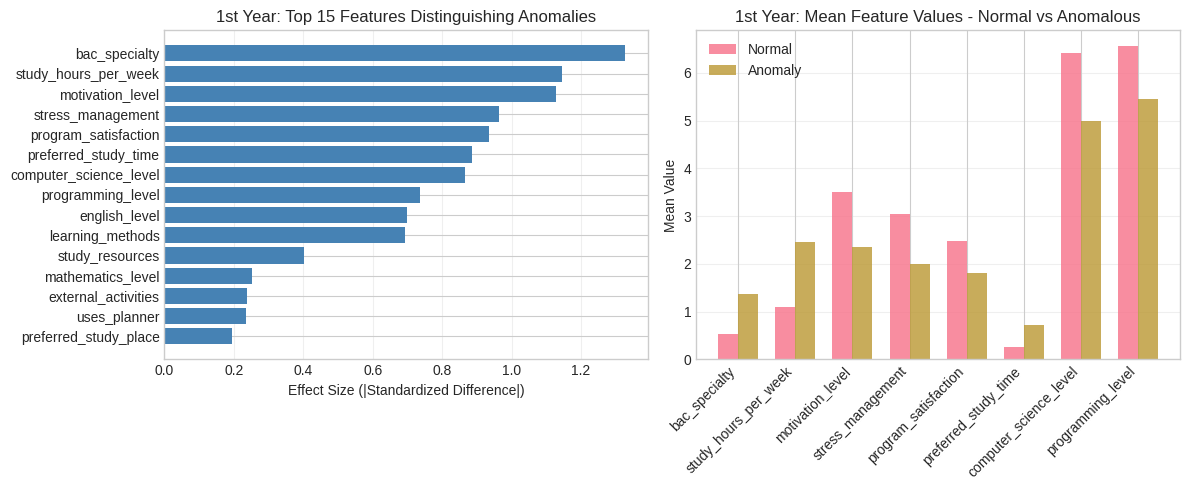

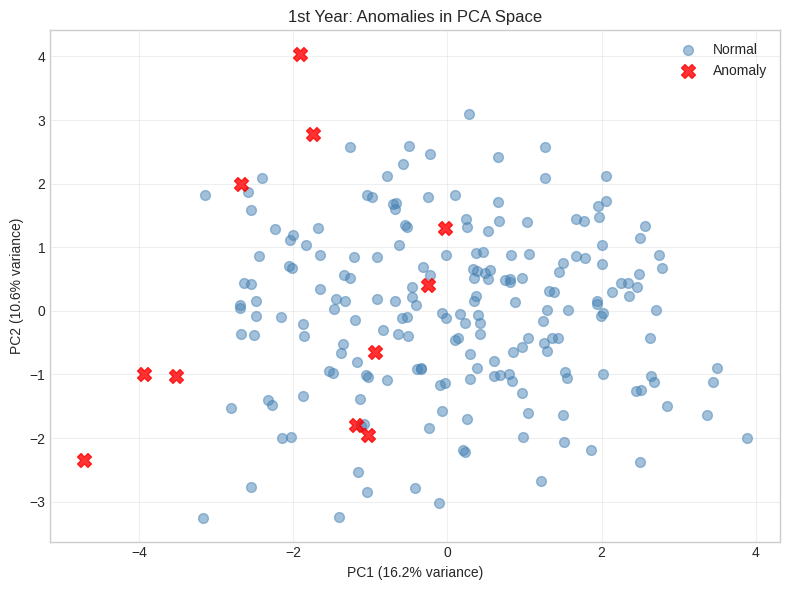

Explained variance by first 2 components: 26.8%


FEATURE-LEVEL ANALYSIS OF ANOMALIES - 2nd Year

Total Students: 101
Anomalies Detected: 5 (4.95%)

Top 10 Distinguishing Features:
['mathematics_level', 'programming_level', 'computer_science_level', 'motivation_level', 'stress_management', 'bac_specialty', 'english_level', 'study_resources', 'program_satisfaction', 'study_hours_per_week']

Top 15 Features by Effect Size:
               Feature  Normal_Mean  Anomaly_Mean  Effect_Size
     mathematics_level     6.989583           3.2     2.760826
     programming_level     7.114583           4.4     2.438391
computer_science_level     7.041667           4.8     1.995922
      motivation_level     3.427083           2.0     1.522280
     stress_management     3.229167           2.0     1.256177
         bac_specialty     0.468750           1.2     1.029748
         english_level     7.718750           6.6     0.937077
       study_resources    17.500000           9.0     0.863091
  progra

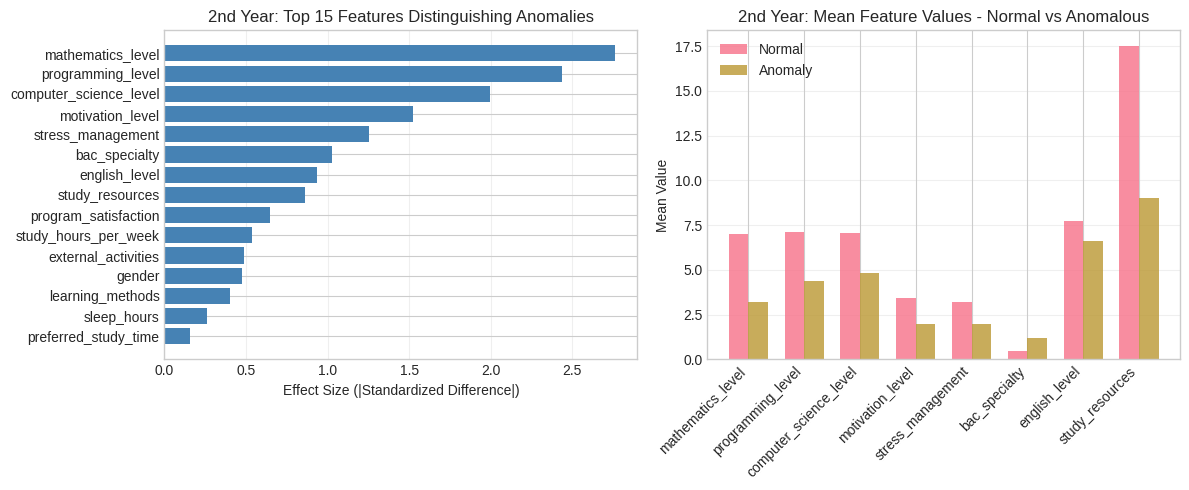

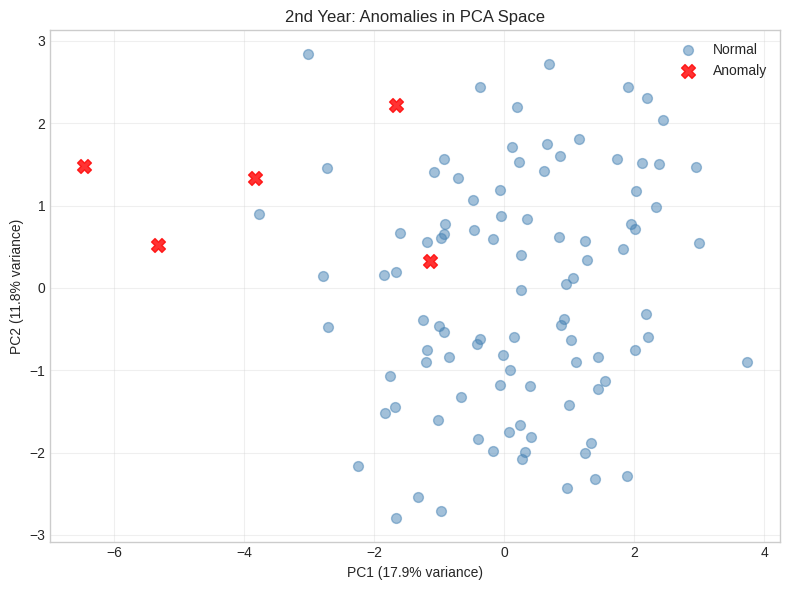

Explained variance by first 2 components: 29.7%


FEATURE-LEVEL ANALYSIS OF ANOMALIES - 3rd Year

Total Students: 12
Anomalies Detected: 1 (8.33%)

Top 10 Distinguishing Features:
['preferred_study_time', 'preferred_study_place', 'gender', 'study_resources', 'bac_specialty', 'uses_planner', 'external_activities', 'learning_methods', 'english_level', 'study_hours_per_week']

Top 15 Features by Effect Size:
              Feature  Normal_Mean  Anomaly_Mean  Effect_Size
 preferred_study_time     0.090909           1.0     3.015103
preferred_study_place     1.727273           0.0     2.671023
               gender     0.272727           1.0     1.556995
      study_resources     4.454545           1.0     1.263721
        bac_specialty     0.363636           1.0     1.261310
         uses_planner     0.636364           0.0     1.261310
  external_activities     0.636364           0.0     1.261310
     learning_methods     5.000000           9.0     1.206045
        english_level     8.00000

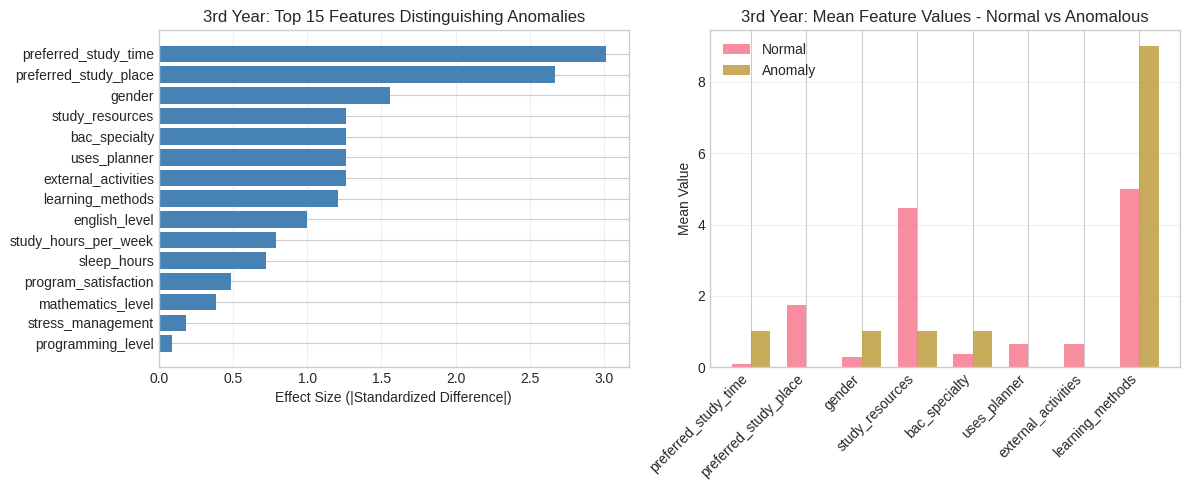

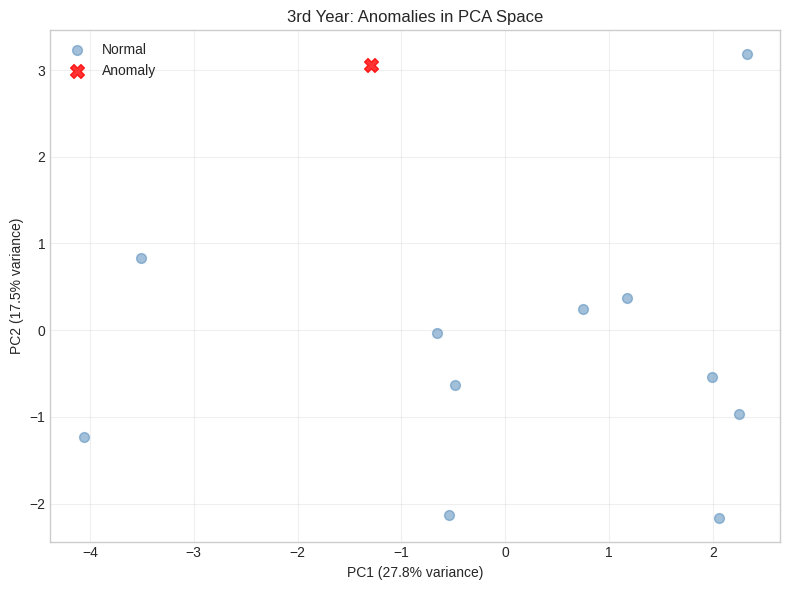

Explained variance by first 2 components: 45.4%




In [29]:
# =============================================================================
# Feature-Level Analysis and Interpretation of Anomalies (All 3 Years)
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def analyze_anomaly_profiles(
    X_raw: pd.DataFrame,
    ensemble_scores: np.ndarray,
    year_name: str,
    top_n: int = 10
) -> dict:
    """
    Analyze characteristics of anomalies at feature level.
    Identifies features that distinguish anomalies from normal students.
    """
    threshold = np.percentile(ensemble_scores, 95)
    anomaly_mask = ensemble_scores > threshold
    
    X_anomalies = X_raw[anomaly_mask]
    X_normal = X_raw[~anomaly_mask]
    
    # Feature-level statistics
    feature_analysis = pd.DataFrame({
        'Feature': X_raw.columns,
        'Normal_Mean': [X_normal[col].mean() for col in X_raw.columns],
        'Normal_Std': [X_normal[col].std() for col in X_raw.columns],
        'Anomaly_Mean': [X_anomalies[col].mean() for col in X_raw.columns],
        'Anomaly_Std': [X_anomalies[col].std() for col in X_raw.columns],
    })
    
    # Compute standardized difference (effect size)
    feature_analysis['Effect_Size'] = np.abs(
        (feature_analysis['Anomaly_Mean'] - feature_analysis['Normal_Mean']) / 
        (feature_analysis['Normal_Std'] + 1e-6)
    )
    
    feature_analysis = feature_analysis.sort_values('Effect_Size', ascending=False)
    
    return {
        'analysis': feature_analysis,
        'n_anomalies': anomaly_mask.sum(),
        'anomaly_rate': 100 * anomaly_mask.sum() / len(anomaly_mask),
        'top_distinguishing_features': feature_analysis.head(top_n)['Feature'].tolist(),
        'anomaly_mask': anomaly_mask
    }

# --------------------------
# Analyze all three years
# --------------------------
years_data = [
    ('1st Year', X_1y_raw, ensemble_1y),
    ('2nd Year', X_2y_raw, ensemble_2y),
    ('3rd Year', X_3y_raw, ensemble_3y)
]

all_years_analysis = {}

for year_name, X_raw, ensemble_scores in years_data:
    print("="*70)
    print(f"FEATURE-LEVEL ANALYSIS OF ANOMALIES - {year_name}")
    print("="*70)
    
    analysis = analyze_anomaly_profiles(X_raw, ensemble_scores, year_name, top_n=10)
    all_years_analysis[year_name] = analysis
    
    print(f"\nTotal Students: {len(X_raw)}")
    print(f"Anomalies Detected: {analysis['n_anomalies']} ({analysis['anomaly_rate']:.2f}%)")
    print(f"\nTop 10 Distinguishing Features:")
    print(analysis['top_distinguishing_features'])
    
    print(f"\nTop 15 Features by Effect Size:")
    top_features_df = analysis['analysis'].head(15)[['Feature', 'Normal_Mean', 'Anomaly_Mean', 'Effect_Size']]
    print(top_features_df.to_string(index=False))
    
    # --------------------------
    # Visualization: Top Features
    # --------------------------
    top_15 = analysis['analysis'].head(15)
    plt.figure(figsize=(12, 5))
    
    # Bar plot of effect sizes
    plt.subplot(1, 2, 1)
    plt.barh(range(len(top_15)), top_15['Effect_Size'].values, color='steelblue')
    plt.yticks(range(len(top_15)), top_15['Feature'].values)
    plt.xlabel('Effect Size (|Standardized Difference|)')
    plt.title(f'{year_name}: Top 15 Features Distinguishing Anomalies')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    
    # Compare means for top 8 features
    top_8_features = analysis['analysis'].head(8)
    x = np.arange(len(top_8_features))
    width = 0.35
    plt.subplot(1, 2, 2)
    plt.bar(x - width/2, top_8_features['Normal_Mean'].values, width, label='Normal', alpha=0.8)
    plt.bar(x + width/2, top_8_features['Anomaly_Mean'].values, width, label='Anomaly', alpha=0.8)
    plt.ylabel('Mean Value')
    plt.xticks(x, top_8_features['Feature'].values, rotation=45, ha='right')
    plt.title(f'{year_name}: Mean Feature Values - Normal vs Anomalous')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --------------------------
    # PCA Visualization
    # --------------------------
    pca_viz = PCA(n_components=2)
    X_scaled = (X_raw - X_raw.mean()) / (X_raw.std() + 1e-6)  # standardize
    X_pca = pca_viz.fit_transform(X_scaled)
    
    anomaly_mask = analysis['anomaly_mask']
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[~anomaly_mask, 0], X_pca[~anomaly_mask, 1], alpha=0.5, s=50, label='Normal', color='steelblue')
    plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], alpha=0.8, s=100, label='Anomaly', color='red', marker='X')
    plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)')
    plt.title(f'{year_name}: Anomalies in PCA Space')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Explained variance by first 2 components: {sum(pca_viz.explained_variance_ratio_[:2])*100:.1f}%\n\n")


## 9. Anomaly Detection Insights 

In [30]:
print("\n" + "="*80)
print("ANOMALY DETECTION - FINAL SUMMARY REPORT")
print("="*80)

# 1. METHODS USED
print("\nMethods Overview (4 Methods): Statistical, kNN, KMeans, Isolation Forest")
print("All methods combined in ensemble scoring to improve robustness and confidence.")

# 2. ANOMALY DETECTION RESULTS
print("\nAnomalies Detected per Year (Ensemble - 95th percentile):")
for year, ensemble_scores, n_students in zip(
    ['1st Year', '2nd Year', '3rd Year'], 
    [ensemble_1y, ensemble_2y, ensemble_3y],
    [len(X_1y_raw), len(X_2y_raw), len(X_3y_raw)]
):
    n_anom = (ensemble_scores > np.percentile(ensemble_scores, 95)).sum()
    rate = 100 * n_anom / n_students
    print(f"  {year}: {n_anom} anomalies ({rate:.2f}%)")

# 3. VOTING / METHOD CONSENSUS
print("\nHigh-Confidence Anomalies (flagged by ≥3 methods):")
for year, votes in zip(['1st Year', '2nd Year', '3rd Year'], [votes_1y, votes_2y, votes_3y]):
    high_conf = (votes >= 3).sum()
    print(f"  {year}: {high_conf} students")

# 4. FEATURE-LEVEL INSIGHTS
analysis_1y = analyze_anomaly_profiles(X_1y_raw, ensemble_1y, "1st Year")
analysis_2y = analyze_anomaly_profiles(X_2y_raw, ensemble_2y, "2nd Year")
analysis_3y = analyze_anomaly_profiles(X_3y_raw, ensemble_3y, "3rd Year")

print("\nTop Features Distinguishing Anomalies (Effect Size):")
for year, analysis in zip(['1st Year', '2nd Year', '3rd Year'], [analysis_1y,analysis_2y, analysis_3y]):
    print(f"  {year}: {', '.join(analysis['top_distinguishing_features'])[:100]}...")  # first few features

# 5. KEY FINDINGS
print("\nKey Findings:")
print("  • Multivariate anomalies detected across features (grades, motivation, attendance, etc.)")
print("  • High-confidence anomalies are most reliable for intervention")
print("  • Ensemble reduces false positives and ensures robustness")
print("  • Smaller datasets (3rd Year) increase variability in anomaly detection confidence")




ANOMALY DETECTION - FINAL SUMMARY REPORT

Methods Overview (4 Methods): Statistical, kNN, KMeans, Isolation Forest
All methods combined in ensemble scoring to improve robustness and confidence.

Anomalies Detected per Year (Ensemble - 95th percentile):
  1st Year: 11 anomalies (5.24%)
  2nd Year: 5 anomalies (4.95%)
  3rd Year: 1 anomalies (8.33%)

High-Confidence Anomalies (flagged by ≥3 methods):
  1st Year: 28 students
  2nd Year: 27 students
  3rd Year: 5 students

Top Features Distinguishing Anomalies (Effect Size):
  1st Year: bac_specialty, study_hours_per_week, motivation_level, stress_management, program_satisfaction, pref...
  2nd Year: mathematics_level, programming_level, computer_science_level, motivation_level, stress_management, b...
  3rd Year: preferred_study_time, preferred_study_place, gender, study_resources, bac_specialty, uses_planner, e...

Key Findings:
  • Multivariate anomalies detected across features (grades, motivation, attendance, etc.)
  • High-confidenc